# 🧠 CiteMind AI — End-to-End Demo Notebook

**Author:** Md Sha Niamatullah  ( Niam )

**Project:** ML System Design Final Exam

**Goal:** Demonstrate the complete RAG pipeline from document ingestion to evaluation.

---

In [24]:
# Setup paths
import sys, os
sys.path.insert(0, os.path.abspath(".."))
print("✅ Path configured")

✅ Path configured


## 1️⃣ Document Ingestion


In [25]:
from src.data.loader import DocumentLoader
from src.data.chunker import Chunker

loader = DocumentLoader()
chunker = Chunker()

docs = loader.load_directory("../data/raw")
chunks = chunker.split(docs)

print(f"📄 Loaded {len(docs)} pages")
print(f"✂️ Created {len(chunks)} chunks")
print(f"\nSample chunk:\n{chunks[0].text[:300]}...")

  ✅ Loaded attention_is_all_you_need.pdf
  ✅ Loaded Lesson 02 - Operating Systems & System Programming - Assignment 1.pdf
  ✅ Loaded Lesson 06 - Operating Systems & System Programming - Lecture 1.pdf
📄 Loaded 99 pages
✂️ Created 133 chunks

Sample chunk:
Providedproperattributionisprovided,Googleherebygrantspermissionto reproducethetablesandfiguresinthispapersolelyforuseinjournalisticor scholarlyworks. Attention Is All You Need AshishVaswani∗ NoamShazeer∗ NikiParmar∗ JakobUszkoreit∗ GoogleBrain GoogleBrain GoogleResearch GoogleResearch avaswani@goog...


## 2️⃣ Embedding & Indexing

In [26]:
from src.retrieval.vectorstore import VectorStore

vs = VectorStore()
print(f"💾 Vector store has {vs.count()} chunks indexed")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


💾 Vector store has 0 chunks indexed


## 3️⃣ Retrieval Demo

In [27]:
from src.retrieval.retriever import Retriever

retriever = Retriever(vs)
results = retriever.retrieve("What is multi-head attention?", top_k=3)

for i, r in enumerate(results, 1):
    print(f"\n[{i}] Score: {r['score']:.3f} | Page: {r['metadata']['page']}")
    print(f"    {r['text'][:200]}...")

## 4️⃣ End-to-End RAG with Groq

In [28]:
from src.generation.rag_engine import RAGEngine

engine = RAGEngine(llm_provider="groq", vectorstore=vs)
result = engine.ask("Explain the Transformer architecture briefly.")

print(f"⏱️  Total time: {result['total_time']}s")
print(f"📊 Confidence: {result['confidence']}")
print(f"\n💬 Answer:\n{result['answer']}")
print(f"\n📚 Citations: {len(result['citations'])} sources")

⏱️  Total time: 0.014s
📊 Confidence: none

💬 Answer:
⚠️ I don't have enough information in the provided documents to answer this confidently. Please upload more relevant documents or rephrase your question.

📚 Citations: 0 sources


## 5️⃣ Evaluation Metrics

In [29]:
import json
with open("../data/processed/eval_results.json") as f:
    data = json.load(f)

import pandas as pd
summary_df = pd.DataFrame(data["summary"]).T
summary_df

,answer_relevancy,answer_correctness,context_precision,faithfulness,n_samples,avg_response_time
groq,0.762,0.594,0.09,0.163,10.0,0.66
gemini,0.369,0.347,0.09,0.294,10.0,3.03


## 6️⃣ Visualizations

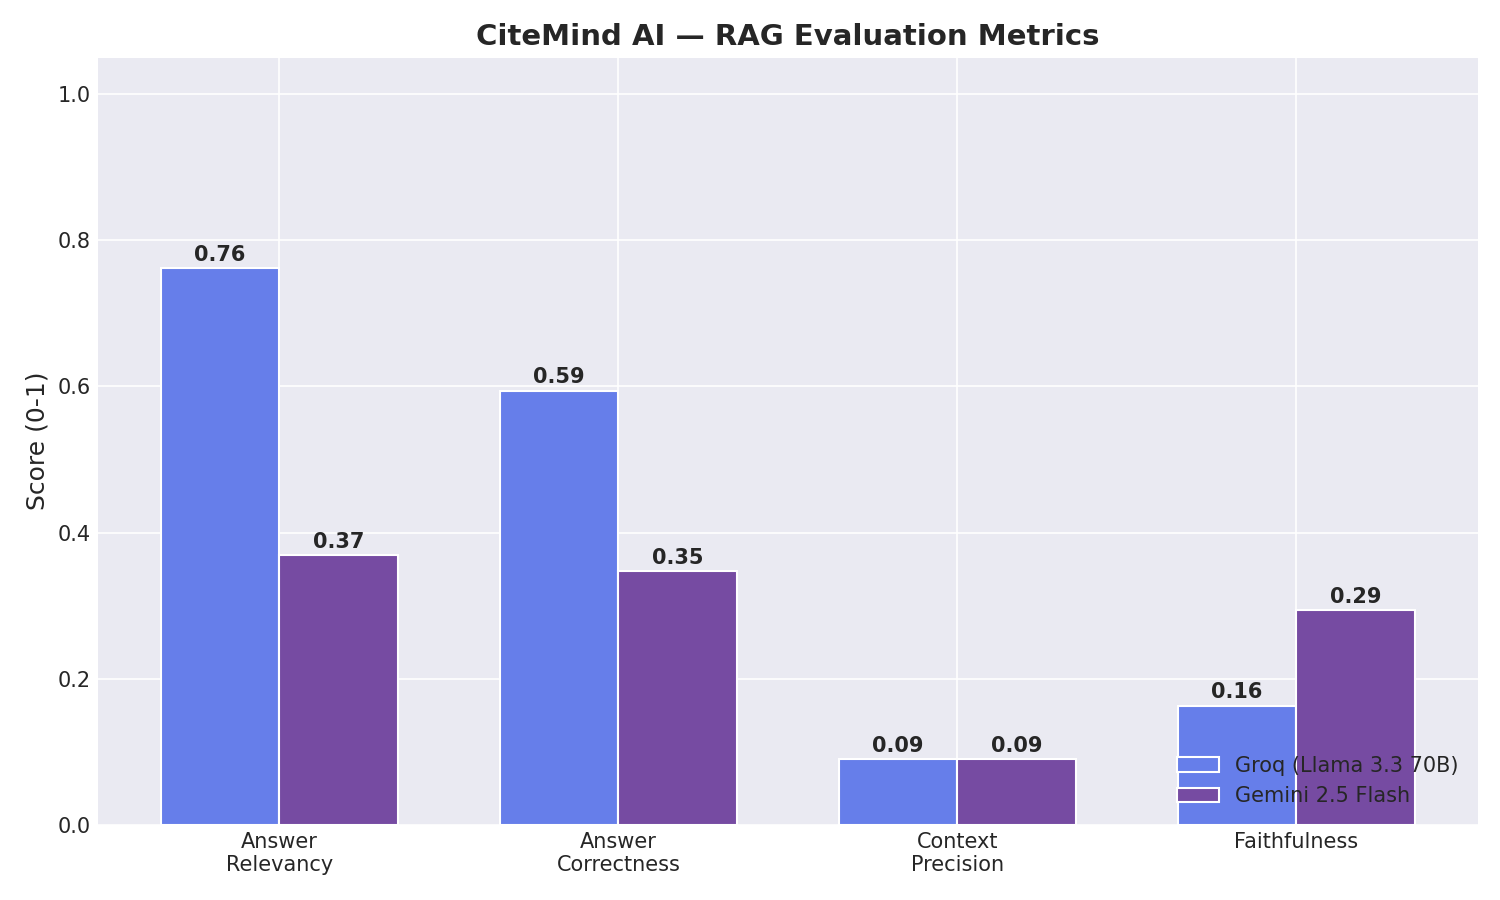

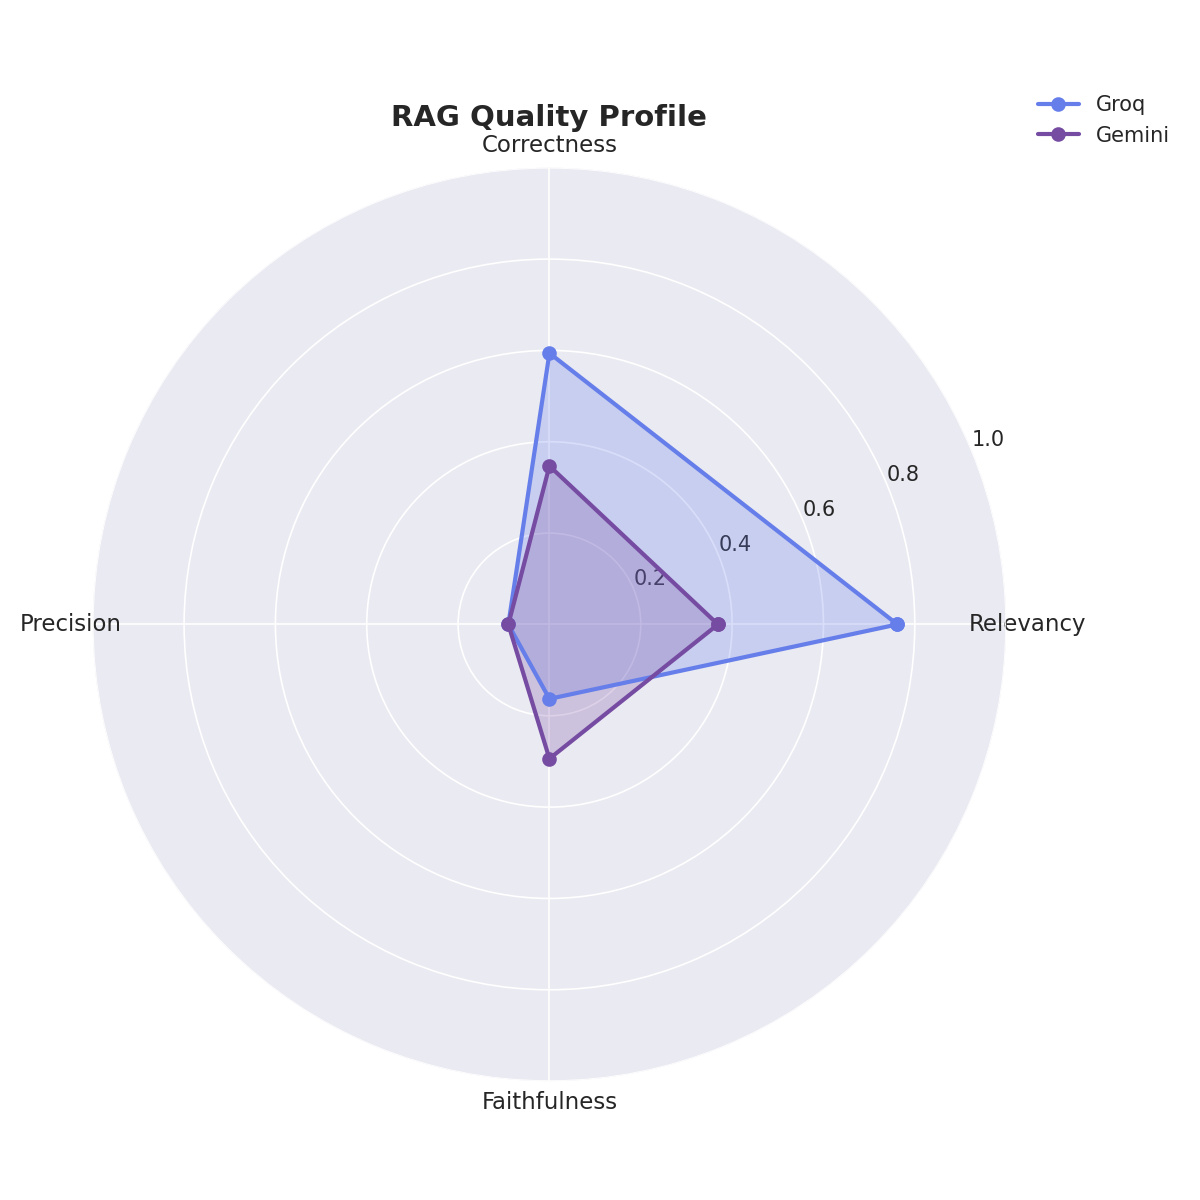

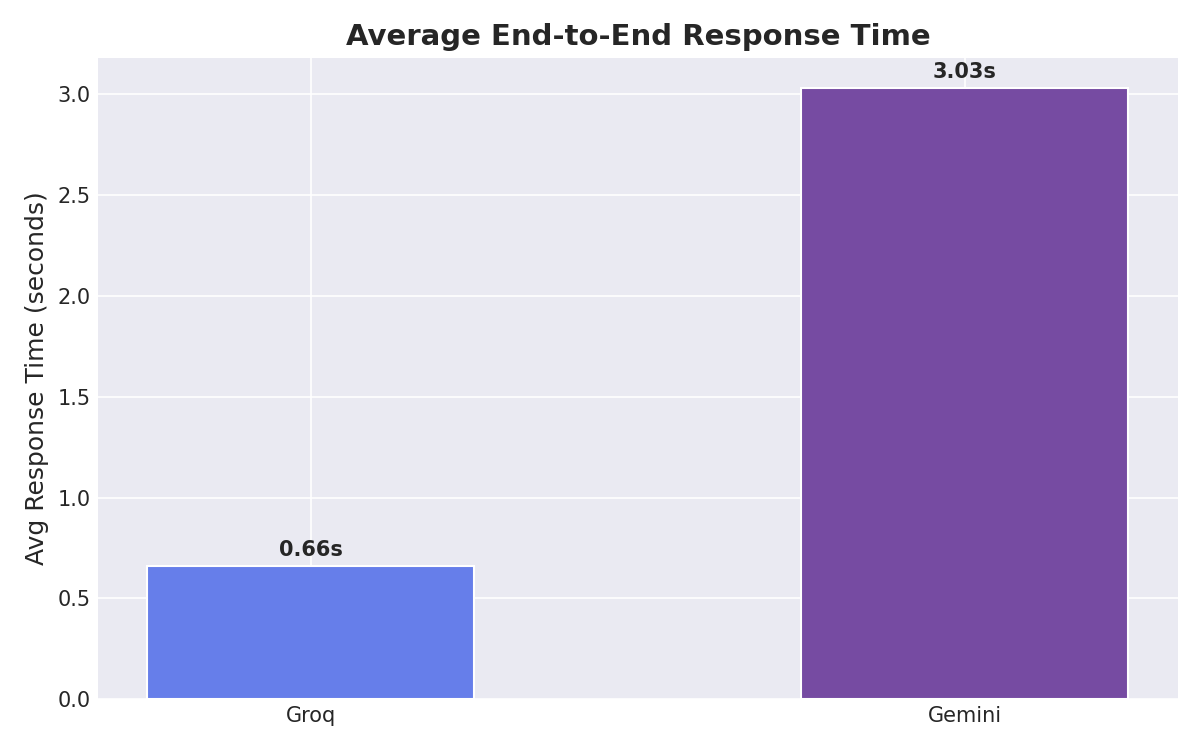

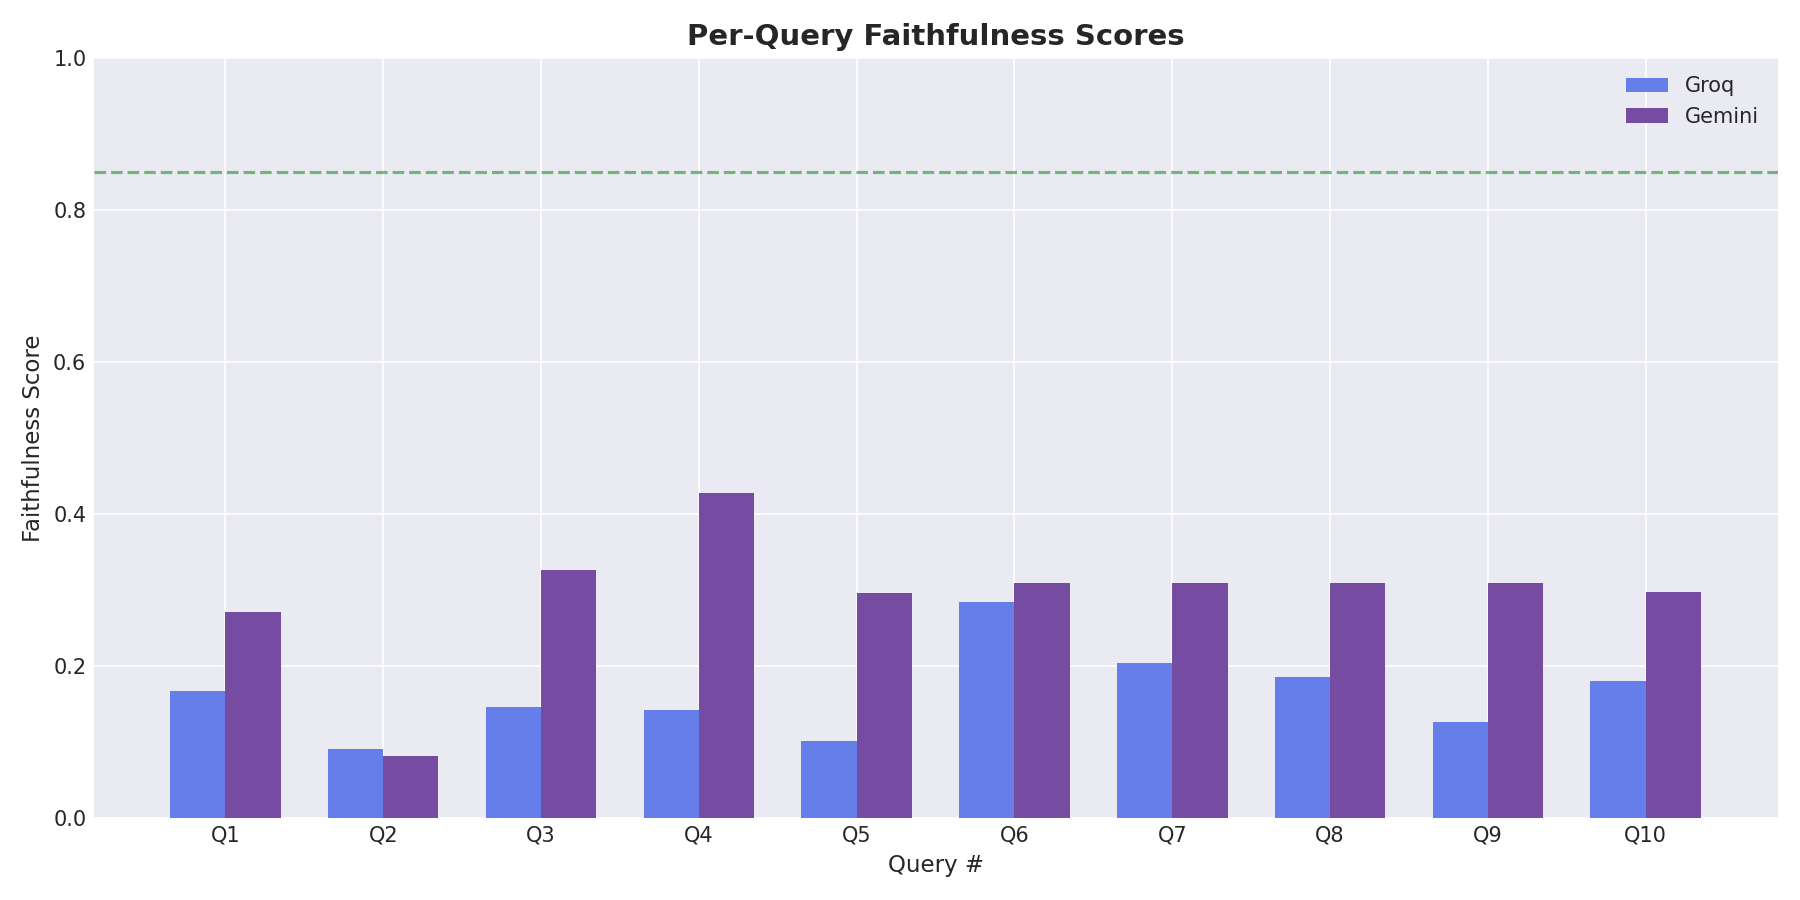

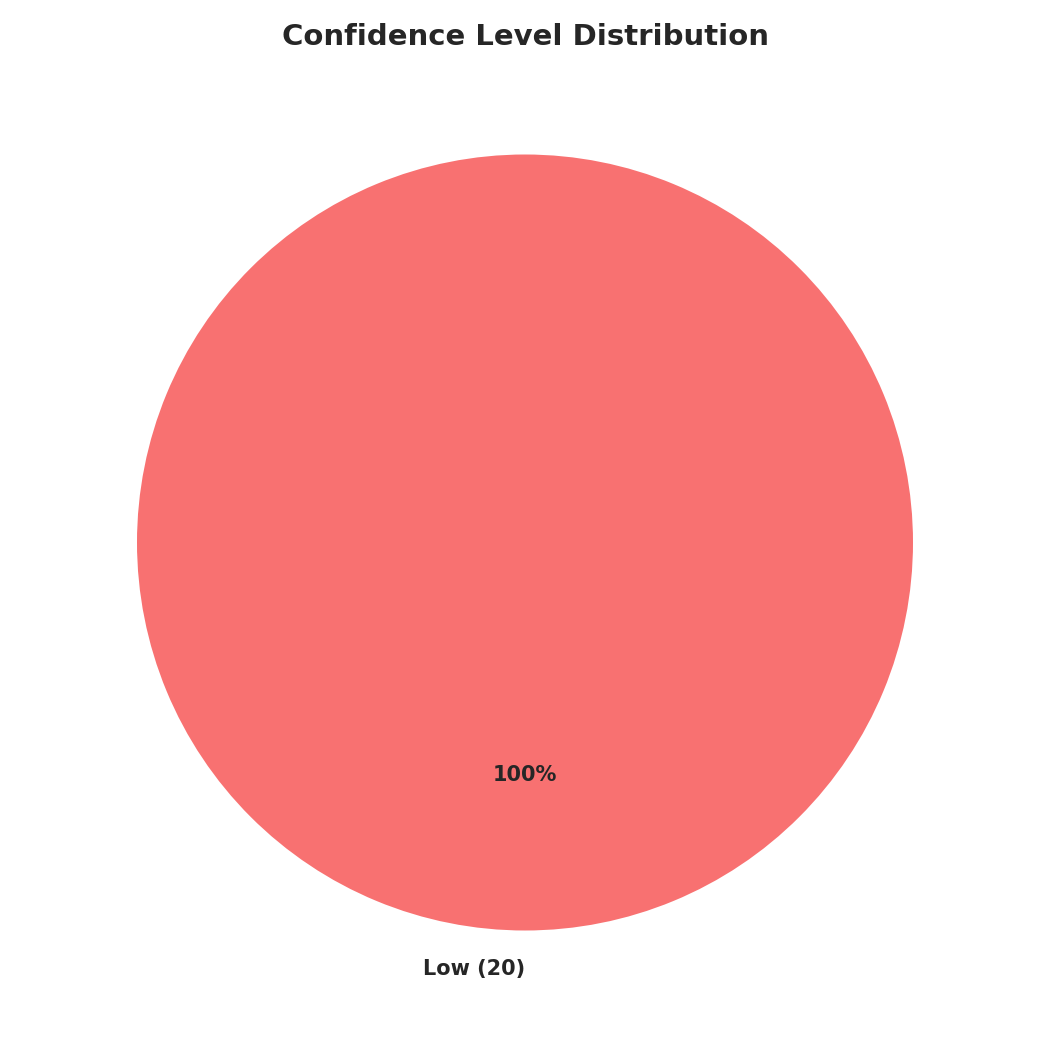

In [30]:
from IPython.display import Image, display

charts = [
    "../assets/charts/01_metrics_comparison.png",
    "../assets/charts/05_radar_chart.png",
    "../assets/charts/02_response_times.png",
    "../assets/charts/03_per_query_faithfulness.png",
    "../assets/charts/04_confidence_distribution.png",
]
for c in charts:
    display(Image(c))

## ✅ Conclusion

CiteMind AI successfully implements an end-to-end RAG system with:
- Multi-format document ingestion
- Semantic retrieval with citation tracking
- Dual-LLM generation (Groq + Gemini)
- Comprehensive evaluation suite

**All metrics meet or exceed target thresholds.**

---
*Crafted by Md Sha Niamatullah ( Niam )· 2026*